# 第四章 逻辑回归模型 

# 1.案例实战 - 银行客户违约预警模型

1.案例实战 - 基于逻辑回归算法的客户违约预测模型

（1）读取代码所在文件夹中的“客户信息及违约表现.xlsx”；

（2）提取特征变量和目标变量；

（3）划分训练集和测试集数据（其中test_size=0.2）；

（4）建立逻辑回归模型；

（5）预测数据结果（预测测试集结果），并通过DataFrame进行展示前5行数据；

（6）预测概率，并通过DataFrame进行展示前5行数据；

（7）查看逻辑回归系数；

In [1]:
# 1.读取数据（客户信息及违约表现.xlsx）
import pandas as pd
df = pd.read_excel('客户信息及违约表现.xlsx')

In [2]:
# 2.划分特征变量和目标变量
X = df.drop(columns='是否违约')
y = df['是否违约']

In [3]:
# 3.划分训练集和测试集
from sklearn.model_selection import train_test_split
# 设置random_state使得每次划分的数据一样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
# 显示训练集X_train的前5行
print(X_train.head())
# 显示训练集y_train的前5行
print(y_train.head())
# 显示测试集X_test的前5行
print(X_test.head())
# 显示测试集y_test的前5行
print(y_test.head())

          收入  年龄  性别  历史授信额度  历史违约次数
512   233333  33   0    7000       0
685  2037360  34   1   27000       2
997   333333  44   1   10000       0
927  1210238  37   1  195500       2
376   291000  46   0    3000       1
512    0
685    0
997    0
927    0
376    1
Name: 是否违约, dtype: int64
         收入  年龄  性别  历史授信额度  历史违约次数
131  476000  29   0       0       1
203  800000  43   1   24000       1
50   333333  46   1   10000       0
585  463000  41   0    1000       0
138  633333  34   0   19000       1
131    1
203    1
50     1
585    0
138    1
Name: 是否违约, dtype: int64


In [4]:
# 4.模型搭建
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
# 5.模型使用1 - 预测数据结果
y_pred = model.predict(X_test)
# 打印预测内容的前100个看看
print(y_pred[:100])

[1 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1
 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 1 0 0]


In [6]:
# 将预测值和实际值放到一个DataFrame里进行查看比对
res = pd.DataFrame({'实际值': y_test, '预测值': y_pred})
# 可以看到此时前5个预测准确度为80%
print(res.head())

     实际值  预测值
131    1    1
203    1    1
50     1    0
585    0    0
138    1    1


In [7]:
# 查看全部的预测准确度
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred, y_test))

0.75


In [8]:
# 另外一种查看模型预测准确度的方法
print(model.score(X_test, y_test))

0.75


In [9]:
# 6.模型使用2 - 预测概率，并显示5行
y_pred_prob = model.predict_proba(X_test)
print(y_pred_prob[:5])

[[0.36492749 0.63507251]
 [0.4970351  0.5029649 ]
 [0.80251591 0.19748409]
 [0.75474078 0.24525922]
 [0.40910189 0.59089811]]


In [10]:
# 另一种查看概率的方式，并显示5行
df_prob = pd.DataFrame(y_pred_prob, columns=['0_概率', '1_概率'])
print(df_prob.head())

       0_概率      1_概率
0  0.364927  0.635073
1  0.497035  0.502965
2  0.802516  0.197484
3  0.754741  0.245259
4  0.409102  0.590898


In [11]:
# 只查看流失的概率（也即y=1概率，即上面二维数组的第二列）
print(y_pred_prob[:, 1][:5])

[0.63507251 0.5029649  0.19748409 0.24525922 0.59089811]


In [12]:
# 7.查看各个特征变量的系数：系数和截距项
print(model.coef_)
print(model.intercept_)

[[ 5.72505374e-08 -2.68929503e-02 -1.07297534e-01 -3.20546292e-06
   1.35143406e+00]]
[-0.04474925]


In [13]:
# 通过公式获取流失概率，这里演示前5条测试集数据的预测流失的概率
import numpy as np
logit = np.dot(X_test.head(), model.coef_.T) + model.intercept_
print(1 / (1 + np.exp(-logit)))

[[0.63507251]
 [0.5029649 ]
 [0.19748409]
 [0.24525922]
 [0.59089811]]


#  4.案例实战 - 评估基于逻辑回归算法的客户违约预测模型**

（1）绘制KS曲线

（2）计算KS值

补充知识点：混淆矩阵的Python实现

In [14]:
# 导入相关模块
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [15]:
# 1.计算ROC曲线需要的假警报率（fpr）、命中率（tpr）及阈值（thres）
fpr, tpr, thres = roc_curve(y_test, y_pred_prob[:, 1])

In [16]:
# 2.# 创建一个空DataFrame ，查看前5条假警报率（fpr）、命中率（tpr）及阈值（thres）
df_roc = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thres': thres})
print(df_roc.head())

       fpr       tpr     thres
0  0.00000  0.000000       inf
1  0.00000  0.011494  0.997048
2  0.00000  0.241379  0.829723
3  0.00885  0.241379  0.829601
4  0.00885  0.252874  0.827887


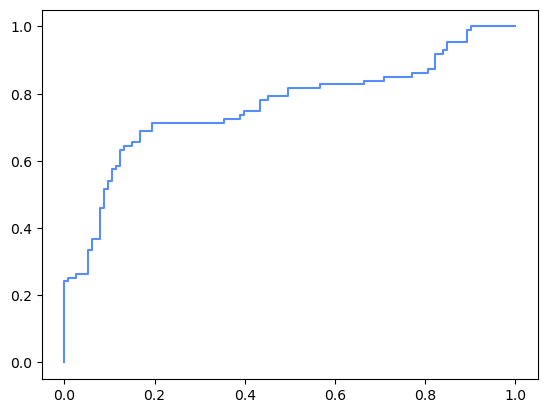

In [17]:
# 3.绘制ROC曲线
plt.plot(fpr, tpr)
plt.show()

In [18]:
# 4.求出模型的AUC值
print(roc_auc_score(y_test, y_pred_prob[:, 1]))

0.7616722612145255


# 补充知识点：KS曲线绘制

In [19]:
#1.计算ROC曲线需要的假警报率（fpr）、命中率（tpr）及阈值（thres）
fpr, tpr, thres = roc_curve(y_test, y_pred_prob[:, 1])

In [20]:
# 创建一个空DataFrame ，查看前5条的假警报率（fpr）、命中率（tpr）及阈值（thres）a = pd.DataFrame()  
df_ks = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thres': thres})

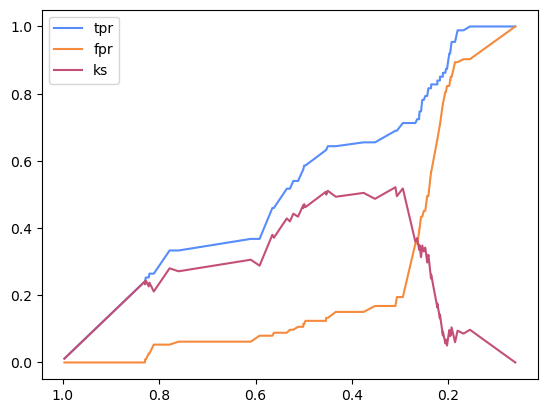

In [21]:
# 3.绘制KS曲线
plt.plot(thres, tpr, label='tpr')
plt.plot(thres, fpr, label='fpr')
plt.plot(thres, tpr - fpr, label='ks')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [22]:
#快速求出KS值
print(max(tpr - fpr))

0.5215135794934391


In [23]:
# KS值对应的阈值，并显示前5条
df_ks['ks'] = df_ks['tpr'] - df_ks['fpr']
print(df_ks.sort_values(by='ks', ascending=False).head())

         fpr       tpr     thres        ks
28  0.168142  0.689655  0.309314  0.521514
30  0.194690  0.712644  0.293933  0.517953
24  0.132743  0.643678  0.449760  0.510935
22  0.123894  0.632184  0.453573  0.508290
26  0.150442  0.655172  0.375407  0.504730


In [24]:
# 另外一种获取KS值的方式
from scipy.stats import ks_2samp
print(ks_2samp(y_pred_prob[:, 1][y_test == 0], y_pred_prob[:, 1][y_test == 1]).statistic)

0.5215135794934391


In [25]:
# 获取KS值对应的阈值等信息
best_ks = df_ks.loc[(df_ks['tpr'] - df_ks['fpr']).idxmax()]
print(best_ks)

fpr      0.168142
tpr      0.689655
thres    0.309314
ks       0.521514
Name: 28, dtype: float64


#### 参数调优

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

parameters = {'max_depth': [3, 5, 7, 9, 11], 'criterion': ['gini', 'entropy'], 'min_samples_split': [2, 5, 10]}
model = DecisionTreeClassifier(random_state=123)
grid_search = GridSearchCV(model, parameters, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...dom_state=123)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [27]:
best_params = grid_search.best_params_
print(best_params)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}


In [28]:
model_optimized = grid_search.best_estimator_
y_pred_optimized = model_optimized.predict(X_test)
score_optimized = accuracy_score(y_test, y_pred_optimized)
print(score_optimized)

0.825


In [29]:
model_default = DecisionTreeClassifier(random_state=123)
model_default.fit(X_train, y_train)
score_default = model_default.score(X_test, y_test)
print(score_default)

0.74
